# Release vs Latest Review Score Analysis

This notebook studies whether Steam review scores changed between each game's release window and its latest all-time score.

The analysis is run separately for the 50 free-to-play games and the 50 paid games.


## Scope

The outcome is the within-game review-score change, defined as `latest_score - release_score`.

Each game contributes two scores: its release-window score and its latest all-time Steam review score. Because the two scores come from the same game, the inference uses a paired t-test. The free-to-play and paid lists are analyzed separately, with 50 games in each group.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

REPO = Path.cwd()
DATA = REPO / "data"


Below are helper functions for processing the data.


In [2]:
def load_review_scores():
    review_scores = pd.read_csv(DATA / "review_scores_paired.csv")
    review_scores = review_scores.rename(columns={
        "Title": "game_name",
        "List": "group",
        "ReleaseScore": "release_score",
        "LatestScore": "latest_score",
        "ReleaseTotal": "release_total_reviews",
        "LatestTotal": "latest_total_reviews",
    })
    review_scores["group"] = review_scores["group"].replace({
        "free": "Free-to-play",
        "paid": "Paid",
    })
    review_scores["release_score"] = pd.to_numeric(review_scores["release_score"], errors="coerce")
    review_scores["latest_score"] = pd.to_numeric(review_scores["latest_score"], errors="coerce")
    review_scores["release_total_reviews"] = pd.to_numeric(review_scores["release_total_reviews"], errors="coerce")
    review_scores["latest_total_reviews"] = pd.to_numeric(review_scores["latest_total_reviews"], errors="coerce")
    review_scores["score_change"] = review_scores["latest_score"] - review_scores["release_score"]
    return review_scores


def run_paired_test(group_frame):
    paired_frame = group_frame.dropna(subset=["release_score", "latest_score"]).copy()
    release_scores = paired_frame["release_score"]
    latest_scores = paired_frame["latest_score"]
    score_changes = paired_frame["score_change"]
    n_games = len(paired_frame)

    mean_change = score_changes.mean()
    standard_deviation = score_changes.std(ddof=1)
    standard_error = standard_deviation / np.sqrt(n_games)
    t_statistic, p_value = stats.ttest_rel(latest_scores, release_scores)
    t_critical = stats.t.ppf(0.975, n_games - 1)
    confidence_interval = (
        mean_change - t_critical * standard_error,
        mean_change + t_critical * standard_error,
    )

    return pd.Series({
        "games": n_games,
        "release_mean": release_scores.mean(),
        "latest_mean": latest_scores.mean(),
        "mean_change": mean_change,
        "t_statistic": t_statistic,
        "p_value": p_value,
        "ci_low": confidence_interval[0],
        "ci_high": confidence_interval[1],
        "cohens_d": mean_change / standard_deviation,
        "shapiro_p": stats.shapiro(score_changes).pvalue,
        "wilcoxon_p": stats.wilcoxon(latest_scores, release_scores).pvalue,
        "shifted_games": int(paired_frame["Shifted"].sum()),
        "capped_games": int(paired_frame["Capped"].sum()),
    })


## Analysis 
First, load the paired data and confirm that the notebook is using the 50 free-to-play games and 50 paid games.


In [3]:
review_scores = load_review_scores()
paired_scores = review_scores.dropna(subset=["release_score", "latest_score"]).copy()

analysis_columns = [
    "game_name",
    "group",
    "release_score",
    "latest_score",
    "score_change",
    "Shifted",
    "Capped",
]

print(f"Games analyzed: {paired_scores.shape[0]}")
print(f"Free-to-play games: {(paired_scores['group'] == 'Free-to-play').sum()}")
print(f"Paid games: {(paired_scores['group'] == 'Paid').sum()}")
print()
print(paired_scores[analysis_columns].head(10).to_string(index=False))

summary = paired_scores.groupby("group")[["release_score", "latest_score", "score_change"]].agg(["count", "mean", "median", "std"])
summary


Games analyzed: 100
Free-to-play games: 50
Paid games: 50

          game_name        group  release_score  latest_score  score_change  Shifted  Capped
   Counter-Strike 2 Free-to-play             94            86            -8     True    True
             Dota 2 Free-to-play             92            81           -11     True    True
PUBG: BATTLEGROUNDS Free-to-play             44            60            16    False    True
       Apex Legends Free-to-play             86            68           -18    False    True
           Warframe Free-to-play             94            88            -6     True   False
        War Thunder Free-to-play             92            72           -20     True   False
           Lost Ark Free-to-play             75            70            -5    False    True
           Unturned Free-to-play             84            91             7    False    True
    Team Fortress 2 Free-to-play             96            91            -5     True    True
        Ove

release_score                          latest_score         \
                     count   mean median        std        count   mean   
group                                                                     
Free-to-play            50  79.58   84.0  15.828275           50  79.56   
Paid                    50  88.50   96.0  13.669943           50  91.20   

                               score_change                          
             median        std        count  mean median        std  
group                                                                
Free-to-play   81.0  12.972750           50 -0.02    0.0  10.005080  
Paid           94.5   7.835034           50  2.70    0.0   9.653698

There are some important notes about the data processed. 
- The paired t-test is release vs latest within the same game, not paid vs free against each other.
- The free-to-play group has 50 paired games and the paid group has 50 paired games.
- `Shifted = True` means the game was released before Steam reviews existed, so the release-window score starts when Steam reviews launched rather than on the true release date.
- `Capped = True` means the release-window score is based on a capped sample of review pages.

Now, run paired t-tests using the release-window and latest scores available in `data/`.


## Score Comparison View

The boxplots compare release-window and latest review scores within each game type.


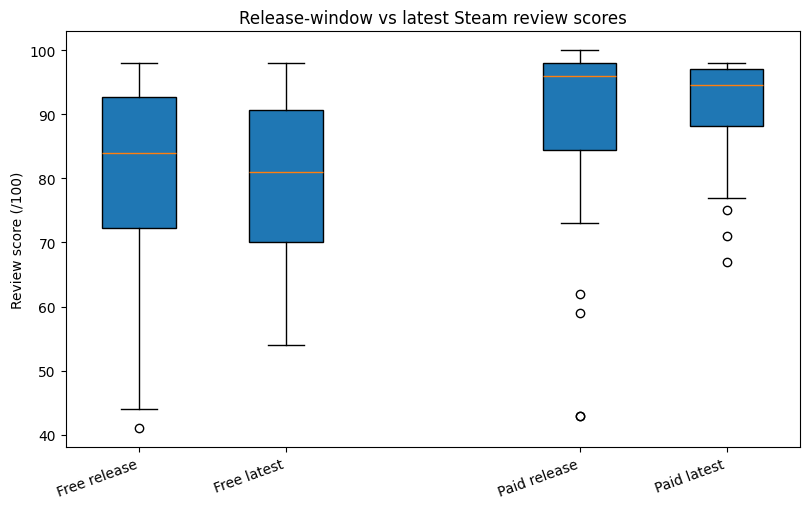

In [4]:
plot_positions = [1, 2, 4, 5]
plot_data = [
    paired_scores.loc[paired_scores["group"] == "Free-to-play", "release_score"],
    paired_scores.loc[paired_scores["group"] == "Free-to-play", "latest_score"],
    paired_scores.loc[paired_scores["group"] == "Paid", "release_score"],
    paired_scores.loc[paired_scores["group"] == "Paid", "latest_score"],
]

fig, ax = plt.subplots(figsize=(8.2, 5.2))
ax.boxplot(plot_data, positions=plot_positions, patch_artist=True)
ax.set_xticks(plot_positions)
ax.set_xticklabels(["Free release", "Free latest", "Paid release", "Paid latest"], rotation=20, ha="right")
ax.set_ylabel("Review score (/100)")
ax.set_title("Release-window vs latest Steam review scores")
fig.tight_layout()


## Change Distribution

The t-tests use each game's score change. A positive value means the latest review score is higher than the release-window score.


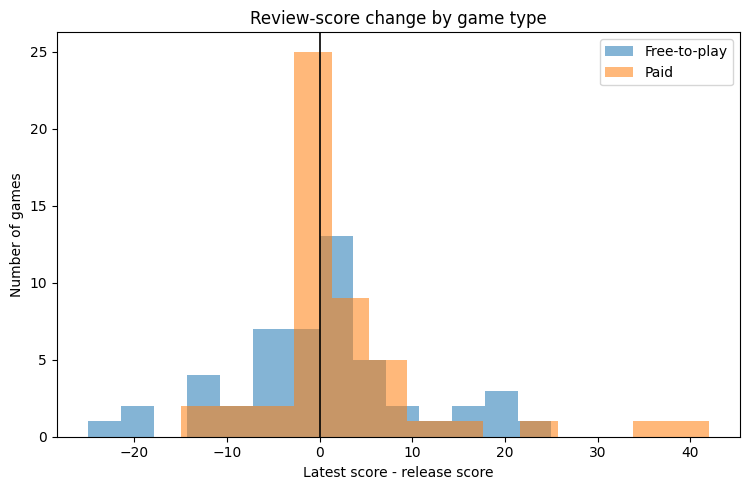

In [5]:
plot_groups = ["Free-to-play", "Paid"]

fig, ax = plt.subplots(figsize=(7.6, 5.0))
for group in plot_groups:
    group_changes = paired_scores.loc[paired_scores["group"] == group, "score_change"]
    ax.hist(group_changes, bins=14, alpha=0.55, label=group)

ax.axvline(0, color="black", linewidth=1.2)
ax.set_xlabel("Latest score - release score")
ax.set_ylabel("Number of games")
ax.set_title("Review-score change by game type")
ax.legend()
fig.tight_layout()


## Paired t-tests by Game Type

H0: within a game type, the average release-to-latest score change is 0.

H1: within a game type, the average release-to-latest score change is not 0.


In [6]:
test_results = pd.DataFrame({
    group: run_paired_test(group_frame)
    for group, group_frame in paired_scores.groupby("group")
}).T
test_results.index.name = "group"

result_columns = [
    "games",
    "release_mean",
    "latest_mean",
    "mean_change",
    "t_statistic",
    "p_value",
    "ci_low",
    "ci_high",
    "cohens_d",
    "shapiro_p",
    "wilcoxon_p",
    "shifted_games",
    "capped_games",
]

test_results = test_results[result_columns]
test_results.round(4)


,games,release_mean,latest_mean,mean_change,t_statistic,p_value,ci_low,ci_high,cohens_d,shapiro_p,wilcoxon_p,shifted_games,capped_games
group,,,,,,,,,,,,,
Free-to-play,50.0,79.58,79.56,-0.02,-0.0141,0.9888,-2.8634,2.8234,-0.0020,0.3192,0.8420,9.0,12.0
Paid,50.0,88.50,91.20,2.70,1.9777,0.0536,-0.0436,5.4436,0.2797,0.0000,0.0868,7.0,32.0


## Mean Change View

The next figure shows the average release-to-latest change for each group with a 95% confidence interval.


,mean,std,count,ci
group,,,,
Free-to-play,-0.02,10.005080,50,2.843412
Paid,2.70,9.653698,50,2.743551


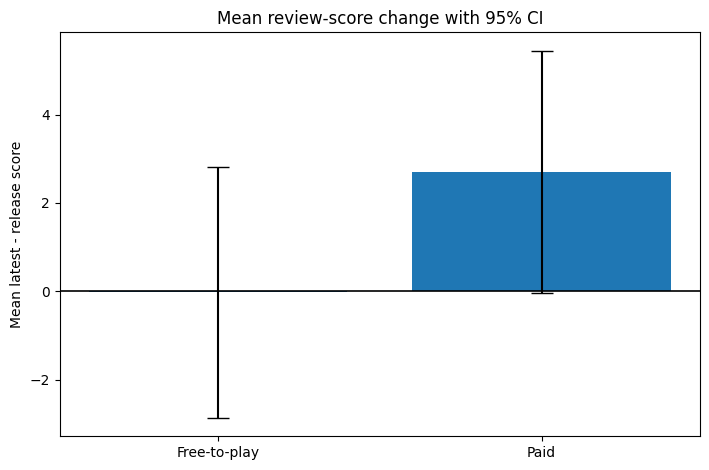

In [7]:
plot_groups = ["Free-to-play", "Paid"]
change_frame = paired_scores.groupby("group")["score_change"].agg(["mean", "std", "count"]).loc[plot_groups]
change_frame["se"] = change_frame["std"] / np.sqrt(change_frame["count"])
change_frame["critical_value"] = stats.t.ppf(0.975, change_frame["count"] - 1)
change_frame["ci"] = change_frame["critical_value"] * change_frame["se"]

fig, ax = plt.subplots(figsize=(7.2, 4.8))
ax.bar(change_frame.index, change_frame["mean"], yerr=change_frame["ci"], capsize=8)
ax.axhline(0, color="black", linewidth=1.2)
ax.set_ylabel("Mean latest - release score")
ax.set_title("Mean review-score change with 95% CI")
fig.tight_layout()

change_frame[["mean", "std", "count", "ci"]]


Test Interpretation
- The free-to-play paired t-test compares release-window score vs latest score for the 50 free games.
- The paid paired t-test compares release-window score vs latest score for the 50 paid games.
- `mean_change` is calculated as `latest_score - release_score`, so positive values mean review scores increased after release.
- The Shapiro-Wilk and Wilcoxon p-values are included because the score-change distributions may not be normal.
- The shifted pre-2013 windows should be treated as a caveat because those release-window scores are not true launch-window scores.
